In [2]:
import pandas as pd 
data = pd.read_csv("MERGED_FINAL.csv") 
data.head()

,main_name,BY,CD,SW_%,KW_%,LF_%,ST_%,Time,Volume,TS_mix_pct,VS_mix_pct,CN_ratio_mix,ISR
0,BY + 40% SW + 60% KW,1,0,40.0,60.0,0.0,0.0,0.000000,0.000000,39.20012,12.396635,4.829316,2.0
1,BY + 40% SW + 60% KW,1,0,40.0,60.0,0.0,0.0,0.198553,38.298758,39.20012,12.396635,4.829316,2.0
2,BY + 40% SW + 60% KW,1,0,40.0,60.0,0.0,0.0,0.201217,38.444227,39.20012,12.396635,4.829316,2.0
3,BY + 40% SW + 60% KW,1,0,40.0,60.0,0.0,0.0,0.203875,38.589697,39.20012,12.396635,4.829316,2.0
4,BY + 40% SW + 60% KW,1,0,40.0,60.0,0.0,0.0,0.206527,38.735166,39.20012,12.396635,4.829316,2.0


In [18]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gompertz(t, P, R_m, lam):
    """
    Modified Gompertz equation for biogas production.
    P: Maximum potential volume
    R_m: Maximum production rate
    lam: Lag phase (lambda)
    """
    e = np.exp(1)
    return P * np.exp(-np.exp((R_m * e / P) * (lam - t) + 1))

# We will collect the extracted kinetics and chemistry for each unique condition
features = []  # Will store [TS_mix, VS_mix, CN_ratio, ISR]
targets = []   # Will store [P_extracted, Rm_extracted, lam_extracted]
reactor_names = []

# Group the dataset by 'main_name' to process each reactor curve independently
for name, group in data.groupby('main_name'):
    # Extract time and volume
    #print(type(group['SW_%'].unique()))
    t_raw = group['Time'].values
    V_raw = group['Volume'].values
    
    # Extract chemical features (assuming they are constant for the specific reactor setting)
    # Using the first row of the group
    ts_mix = group['TS_mix_pct'].iloc[0]
    vs_mix = group['VS_mix_pct'].iloc[0]
    cn_mix = group['CN_ratio_mix'].iloc[0]
    isr = group['ISR'].iloc[0]
    
    sw= group['SW_%'].iloc[0]
    by = group['BY'].iloc[0]
    cd= group['CD'].iloc[0]
    kw= group['KW_%'].iloc[0]
    lf= group['LF_%'].iloc[0]
    st= group['ST_%'].iloc[0]
    
    
    
    
    
    # ---------------------------------------------------------
    # Curve Fitting: Estimate Initial Guesses (Intelligent p0)
    # ---------------------------------------------------------
    P_guess = np.max(V_raw) if np.max(V_raw) > 0 else 1.0
    
    # Calculate discrete derivative to find max slope (R_m)
    dt = np.diff(t_raw)
    dV = np.diff(V_raw)
    # prevent division by zero
    dt[dt == 0] = 1e-6
    slopes = dV / dt
    Rm_guess = np.max(slopes) if np.max(slopes) > 0 else 1.0
    
    # Estimate lambda: time where Volume exceeds 5% of max volume
    threshold = 0.05 * P_guess
    lam_indices = np.where(V_raw > threshold)[0]
    lam_guess = t_raw[lam_indices[0]] if len(lam_indices) > 0 else 0.0
    
    # ---------------------------------------------------------
    # Run Optimizer (Levenberg-Marquardt algorithm)
    # Bounds enforce biological reality: P > 0, Rm > 0, lam >= 0
    # ---------------------------------------------------------
    try:
        popt, pcov = curve_fit(
            gompertz, 
            t_raw, 
            V_raw, 
            p0=[P_guess, Rm_guess, lam_guess],
            bounds=(0, [np.inf, np.inf, np.inf]),
            maxfev=10000
        )
        P_ext, Rm_ext, lam_ext = popt
        
        # Save features and successfully extracted targets
        features.append([ts_mix, vs_mix, cn_mix, isr ]) #, sw, by, cd, kw, lf, st])
        targets.append([P_ext, Rm_ext, lam_ext])
        reactor_names.append(name)
        
    except Exception as e:
        print(f"Failed to fit Gompertz curve for {name}: {e}")

# Convert lists to NumPy arrays for ML training
X = np.array(features)
Y = np.array(targets)

print(f"Successfully extracted parameters for {len(X)} reactors.")
print("Feature matrix shape:", X.shape)
print("Target matrix shape:", Y.shape)

Successfully extracted parameters for 31 reactors.
Feature matrix shape: (31, 4)
Target matrix shape: (31, 3)


In [20]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# -------------------------------------------------------------
# XGBoost Training Pipeline Strategy
# XGBoost can easily overfit on tiny datasets (N=15), so we use
# strong regularization, shallow trees, and slow learning.
# -------------------------------------------------------------

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=42)

# Define heavily regularized XGBoost for low-sample robustness
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=3,            # Shallow trees to prevent complex splits on small data
    learning_rate=0.03,     # Slow learning rate
    subsample=0.8,          # Stochasticity to reduce overfitting
    colsample_bytree=0.8,
    reg_lambda=5.0,         # Strong L2 regularization
    reg_alpha=1.0,          # L1 regularization for sparsity
    random_state=42
)

# Use MultiOutputRegressor to predict P, R_m, and lambda simultaneously
xgb_model = MultiOutputRegressor(xgb_base)

print("Training Multi-Output XGBoost Model on X = [TS, VS, C/N, ISR] to predict Y = [P, Rm, λ]...")
xgb_model.fit(X_train, Y_train)

# -------------------------------------------------------------
# Evaluation Strategy
# -------------------------------------------------------------
Y_pred_train = xgb_model.predict(X_train)
Y_pred_test = xgb_model.predict(X_test)

# Unscale back to biological units
Y_train_orig = scaler_Y.inverse_transform(Y_train)
Y_pred_train_orig = scaler_Y.inverse_transform(Y_pred_train)

Y_test_orig = scaler_Y.inverse_transform(Y_test)
Y_pred_test_orig = scaler_Y.inverse_transform(Y_pred_test)

# Report performance on testing
mae_test = mean_absolute_error(Y_test_orig, Y_pred_test_orig)
r2_test = r2_score(Y_test_orig, Y_pred_test_orig)

print(f"\nXGBoost Test Performance on Kinematic Parameters:")
print(f"Mean Absolute Error: {mae_test:.3f}")
print(f"R-squared Score: {r2_test:.3f}")

# Example Inference
# --------------------------------------------------------------
# X_unseen = np.array([[40.2, 12.5, 4.8, 2.0]])
# X_unseen_scaled = scaler_X.transform(X_unseen)

# Y_pred_unseen_scaled = xgb_model.predict(X_unseen_scaled)
# Y_pred_unseen = scaler_Y.inverse_transform(Y_pred_unseen_scaled)

# P_pred, Rm_pred, lam_pred = Y_pred_unseen[0]
# print(f"\nExample Prediction on Unseen Data (TS=40.2%, VS=12.5, C/N=4.8, ISR=2.0)")
# print(f"  Predicted Max Volume P: {P_pred:.2f}")
# print(f"  Predicted Rate Rm: {Rm_pred:.2f}")
# print(f"  Predicted Lag λ: {lam_pred:.2f}")

Training Multi-Output XGBoost Model on X = [TS, VS, C/N, ISR] to predict Y = [P, Rm, λ]...

XGBoost Test Performance on Kinematic Parameters:
Mean Absolute Error: 54.917
R-squared Score: -6.075


Pipeline Performance Summary:
                             main_name    test_r2      P_pred    Rm_pred
0     CD + 68.5% SW + 30% KW + 1.5% LF -42.101583  237.591553  22.629572
1                              CD + SW -18.228114  247.922058  37.041695
2     CD + 62.5% SW + 30% KW + 7.5% LF  -5.579972  147.050827  14.995404
3                 CD + 40% SW + 60% KW  -4.122135  348.728790  26.613472
4                              CD + KW  -3.993925  424.663635  14.508317
5         CD + 65% SW + 30% KW + 5% LF  -3.042123  109.332809  14.383386
6                         CD + BY + SW  -2.037413  217.136826  56.423801
7   CD + BY + 60% SW + 30% KW + 10% ST  -1.283507  172.550385  54.199112
8        CD + 60% SW + 30% KW + 10% ST  -0.819791  165.431259  17.655172
9     CD + 68.5% SW + 30% KW + 1.5% ST  -0.335511  427.804901  13.236929
10                             BY + SW  -0.310978  193.117523  59.988091
11        CD + 65% SW + 30% KW + 5% ST  -0.140822  364.126129  14.339905
12       BY + 60% SW 

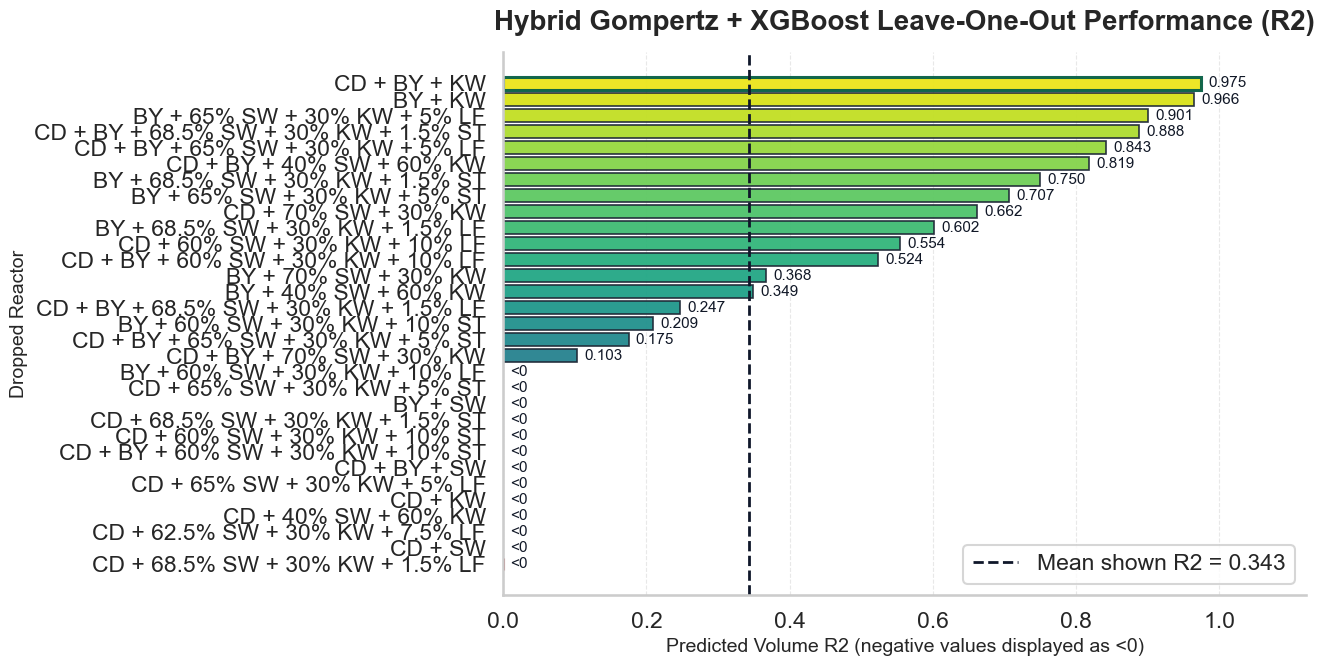

In [21]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

unique_names = np.array(reactor_names)
results = []

# Perform Leave-One-Out Cross-Validation at the Reactor Level
for dropped_name in set(unique_names):
    # Setup train/test masks
    train_mask = unique_names != dropped_name
    test_mask = unique_names == dropped_name
    
    X_train, Y_train = X[train_mask], Y[train_mask]
    X_test, Y_test = X[test_mask], Y[test_mask]
    
    # Scale specific to this fold to avoid data leakage
    sc_X = StandardScaler()
    sc_Y = StandardScaler()
    
    X_train_scaled = sc_X.fit_transform(X_train)
    Y_train_scaled = sc_Y.fit_transform(Y_train)
    X_test_scaled = sc_X.transform(X_test)
    
    # Train heavily regularized XGBoost
    xgb_base = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=1.0,
        random_state=42
    )
    model = MultiOutputRegressor(xgb_base)
    model.fit(X_train_scaled, Y_train_scaled)
    
    # Predict kinetic parameters for the dropped reactor
    y_test_pred_scaled = model.predict(X_test_scaled)
    y_test_pred = sc_Y.inverse_transform(y_test_pred_scaled)
    
    P_pred, Rm_pred, lam_pred = y_test_pred[0]
    
    # Reconstruct the volume curve using Gompertz
    reactor_data = data[data['main_name'] == dropped_name]
    t_actual = reactor_data['Time'].values
    V_actual = reactor_data['Volume'].values
    
    V_pred = gompertz(t_actual, P_pred, Rm_pred, lam_pred)
    
    # Evaluate performance on the full generated curve vs actual time series
    test_r2 = r2_score(V_actual, V_pred)
    
    results.append({
        "main_name": dropped_name,
        "n_test_rows": len(V_actual),
        "test_r2": test_r2,
        "P_pred": P_pred,
        "Rm_pred": Rm_pred,
        "lam_pred": lam_pred
    })

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=True).reset_index(drop=True)
print("Pipeline Performance Summary:")
print(results_df[["main_name", "test_r2", "P_pred", "Rm_pred"]].head(15))

# ----------------- PLOTTING -----------------
plot_df = results_df.copy()
# Clip at lower bound 0 for graphing, so massive negatives don't destroy chart scales
plot_df["plot_r2"] = plot_df["test_r2"].clip(lower=0) 
plot_df["label_r2"] = plot_df["test_r2"].apply(lambda v: "<0" if v < 0 else f"{v:.3f}")

mean_plot_r2 = plot_df["plot_r2"].mean()

fig, ax = plt.subplots(figsize=(13.5, 7))
colors = sns.color_palette("viridis", n_colors=len(plot_df))

bars = ax.barh(
    y=plot_df["main_name"],
    width=plot_df["plot_r2"],
    color=colors,
    edgecolor="#1f2937",
    linewidth=1.2,
    alpha=0.95
)

best_idx = plot_df["test_r2"].idxmax()
worst_idx = plot_df["test_r2"].idxmin()
for i, idx in enumerate(plot_df.index):
    if idx == best_idx:
        bars[i].set_edgecolor("#065f46")
        bars[i].set_linewidth(2.2)
    elif idx == worst_idx:
        bars[i].set_edgecolor("#991b1b")
        bars[i].set_linewidth(2.2)

ax.axvline(mean_plot_r2, color="#0f172a", linestyle="--", linewidth=2, label=f"Mean shown R2 = {mean_plot_r2:.3f}")

for bar, shown_value, label_value in zip(bars, plot_df["plot_r2"], plot_df["label_r2"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    text_x = x + 0.01 if x > 0 else 0.01
    ax.text(text_x, y, label_value, va="center", ha="left", fontsize=11, color="#111827")

max_x = max(0.05, plot_df["plot_r2"].max() * 1.15)
ax.set_xlim(0, max_x)

ax.set_title("Hybrid Gompertz + XGBoost Leave-One-Out Performance (R2)", fontsize=20, pad=16, weight="bold")
ax.set_xlabel("Predicted Volume R2 (negative values displayed as <0)", fontsize=14)
ax.set_ylabel("Dropped Reactor", fontsize=14)
ax.legend(frameon=True, fancybox=True)
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.45)
ax.grid(axis="y", visible=False)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

Failed to fit temporal curve for CD + 65% SW + 30% KW + 5% LF on train split: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Failed to fit temporal curve for CD + 68.5% SW + 30% KW + 1.5% LF on train split: Optimal parameters not found: The maximum number of function evaluations is exceeded.
========= 70/30 Temporal Split Gompertz Evaluation =========


,main_name,Train_R2,Test_R2,Test_MAE
0,CD + BY + KW,0.995122,0.872463,1.284565
1,CD + 60% SW + 30% KW + 10% LF,0.982924,-8.246085,12.322432
2,CD + BY + 68.5% SW + 30% KW + 1.5% ST,0.997153,-8.309573,12.876232
3,BY + 60% SW + 30% KW + 10% LF,0.997470,-8.473433,15.648701
4,CD + 40% SW + 60% KW,0.984727,-8.526381,12.672348
5,CD + BY + 60% SW + 30% KW + 10% LF,0.981314,-13.957391,26.812129
6,CD + 60% SW + 30% KW + 10% ST,0.995078,-20.382924,5.745716
7,BY + KW,0.991401,-23.576919,27.601194
8,BY + 70% SW + 30% KW,0.987795,-25.881184,12.092932
9,CD + BY + 70% SW + 30% KW,0.993716,-29.194446,32.818632


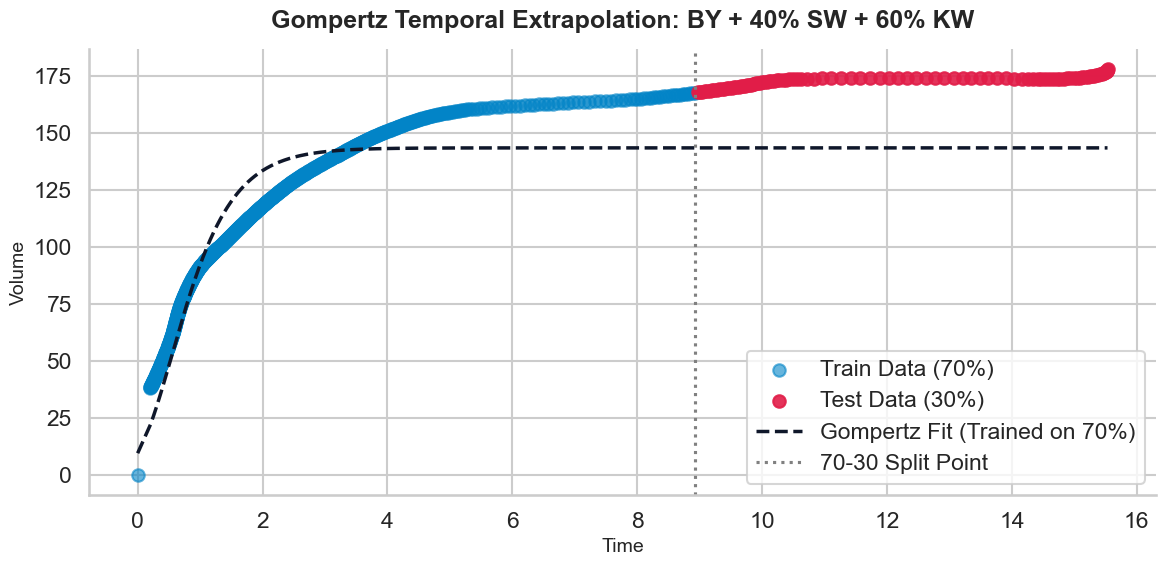

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

# -------------------------------------------------------------
# Evaluating Gompertz Model Temporal Fit vs XGBoost (70-30 Train/Test Split)
# Here we test how well the analytical Gompertz model fits 
# early temporal data (70%) and predicts the later unseen data (30%)
# compared to a global XGBoost model trained on Time + Composition.
# -------------------------------------------------------------

temporal_results = []
plot_reactor = None

# Data collection for global XGBoost training
X_train_xgb_list = []
y_train_xgb_list = []
X_test_xgb_list = []
y_test_xgb_list = []

xgb_features = ['Time', 'SW_%', 'BY', 'CD', 'KW_%', 'LF_%', 'ST_%']

for name, group in data.groupby('main_name'):
    # Sort strictly by time to ensure temporal splitting is valid
    group = group.sort_values(by='Time')
    
    # 70-30 Temporal Split
    split_idx = int(len(group) * 0.70)
    
    train_group = group.iloc[:split_idx]
    test_group = group.iloc[split_idx:]
    
    t_train = train_group['Time'].values
    V_train = train_group['Volume'].values
    t_test = test_group['Time'].values
    V_test = test_group['Volume'].values
    
    # Collect data for XGBoost
    X_train_xgb_list.append(train_group[xgb_features])
    y_train_xgb_list.append(V_train)
    X_test_xgb_list.append(test_group[xgb_features])
    y_test_xgb_list.append(V_test)
    
    # Intelligent Initial Guesses based ONLY on train data
    P_guess = np.max(V_train) if np.max(V_train) > 0 else 1.0
    dt = np.diff(t_train)
    dV = np.diff(V_train)
    dt[dt == 0] = 1e-6
    slopes = dV / dt
    Rm_guess = np.max(slopes) if len(slopes) > 0 and np.max(slopes) > 0 else 1.0
    
    threshold = 0.05 * P_guess
    lam_indices = np.where(V_train > threshold)[0]
    lam_guess = t_train[lam_indices[0]] if len(lam_indices) > 0 else 0.0
    
    try:
        # Fit Gompertz on 70% Train temporal data
        popt, _ = curve_fit(
            gompertz, 
            t_train, 
            V_train, 
            p0=[P_guess, Rm_guess, lam_guess],
            bounds=(0, [np.inf, np.inf, np.inf]),
            maxfev=10000
        )
        
        V_test_pred_gomp = gompertz(t_test, *popt)
        
        train_r2_gomp = r2_score(V_train, gompertz(t_train, *popt)) if len(V_train) > 1 else np.nan
        test_r2_gomp = r2_score(V_test, V_test_pred_gomp) if len(V_test) > 1 else np.nan
        test_mae_gomp = mean_absolute_error(V_test, V_test_pred_gomp) if len(V_test) > 0 else np.nan
        
        temporal_results.append({
            "main_name": name,
            "Gompertz_Train_R2": train_r2_gomp,
            "Gompertz_Test_R2": test_r2_gomp,
            "Gompertz_Test_MAE": test_mae_gomp,
            "popt": popt,
            "train_group": train_group,
            "test_group": test_group,
            "t_train": t_train,
            "V_train": V_train,
            "t_test": t_test,
            "V_test": V_test
        })
        
    except Exception as e:
        print(f"Failed to fit Gompertz curve for {name} on train split: {e}")

# ----------------- Train Global XGBoost -----------------
X_train_xgb = pd.concat(X_train_xgb_list, ignore_index=True)
y_train_xgb = np.concatenate(y_train_xgb_list)
X_test_xgb = pd.concat(X_test_xgb_list, ignore_index=True)
y_test_xgb = np.concatenate(y_test_xgb_list)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42
)
print("Training global XGBoost model on temporal 70% split data...")
xgb_model.fit(X_train_xgb, y_train_xgb)

# ----------------- Evaluate Both & Find Plot Example -----------------
final_results = []
for res in temporal_results:
    # Predict Train and Test with XGBoost
    V_train_pred_xgb = xgb_model.predict(res["train_group"][xgb_features])
    V_test_pred_xgb = xgb_model.predict(res["test_group"][xgb_features])
    
    test_r2_xgb = r2_score(res["V_test"], V_test_pred_xgb) if len(res["V_test"]) > 1 else np.nan
    test_mae_xgb = mean_absolute_error(res["V_test"], V_test_pred_xgb) if len(res["V_test"]) > 0 else np.nan
    
    final_results.append({
        "main_name": res["main_name"],
        "Gomp_Test_R2": res["Gompertz_Test_R2"],
        "XGB_Test_R2": test_r2_xgb,
        "Gomp_Test_MAE": res["Gompertz_Test_MAE"],
        "XGB_Test_MAE": test_mae_xgb
    })
    
    # Save the first successful reactor for plotting
    if plot_reactor is None:
        plot_reactor = {
            "name": res["main_name"],
            "t_train": res["t_train"], 
            "V_train": res["V_train"],
            "t_test": res["t_test"], 
            "V_test": res["V_test"],
            "popt": res["popt"],
            "V_train_pred_xgb": V_train_pred_xgb,
            "V_test_pred_xgb": V_test_pred_xgb
        }

results_df = pd.DataFrame(final_results).sort_values("Gomp_Test_R2", ascending=False).reset_index(drop=True)

print("\n========= 70/30 Temporal Extrapolation: Gompertz vs XGBoost =========")
display(results_df)

# ----------------- PLOTTING ONE EXAMPLE -----------------
if plot_reactor is not None:
    plt.figure(figsize=(13, 7))
    
    t_train = plot_reactor["t_train"]
    t_test = plot_reactor["t_test"]
    t_full = np.concatenate([t_train, t_test])
    
    # Reconstruct predictions for full plot lines
    V_full_pred_gomp = gompertz(t_full, *plot_reactor["popt"])
    V_full_pred_xgb = np.concatenate([plot_reactor["V_train_pred_xgb"], plot_reactor["V_test_pred_xgb"]])
    
    # Actual Data Scatters
    plt.scatter(t_train, plot_reactor["V_train"], color='#0284c7', s=40, label='Train Data (70%)', alpha=0.5)
    plt.scatter(t_test, plot_reactor["V_test"], color='#e11d48', s=40, label='Test Data (30%)', alpha=0.8)
    
    # Model Lines
    plt.plot(t_full, V_full_pred_gomp, color='#0f172a', linewidth=2.5, linestyle='-', label='Gompertz Extrapolation')
    plt.plot(t_full, V_full_pred_xgb, color='#16a34a', linewidth=2.5, linestyle='-.', label='Global XGBoost Prediction')
    
    # Split visual marker
    if len(t_train) > 0:
        plt.axvline(t_train[-1], color='gray', linestyle=':', label='70-30 Split Point')
    
    plt.title(f"Temporal Extrapolation Comparison: {plot_reactor['name']}", fontsize=18, weight="bold", pad=15)
    plt.xlabel("Time", fontsize=14)
    plt.ylabel("Volume", fontsize=14)
    plt.legend(frameon=True, fancybox=True)
    sns.despine()
    plt.tight_layout()
    plt.show()